# 1. Dataset Description

## Dataset Information

* **Dataset Name:** Medical Cost Personal Dataset
* **Source:** Kaggle
* **Link:** [https://www.kaggle.com/datasets/mirichoi0218/insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## Contextual Description of the Dataset

The *Medical Cost Personal Dataset* contains information about individuals who are beneficiaries of health insurance in the United States. The dataset captures a combination of demographic, lifestyle, and health-related attributes that are commonly associated with variations in medical expenses. The primary objective of the dataset is to understand and predict individual medical insurance charges based on these factors.

This dataset is widely used in introductory data science and machine learning tasks because it reflects a real-world problem faced by insurance companies: estimating medical costs for individuals in order to price insurance plans appropriately.

## Variables in the Dataset

The dataset consists of the following variables:

* **age** (Numerical): Age of the primary insurance beneficiary.
* **sex** (Categorical): Gender of the insurance contractor (male or female).
* **bmi** (Numerical): Body Mass Index (BMI), calculated as weight (kg) divided by height squared (m²). It provides an objective measure of body weight relative to height. A BMI between 18.5 and 24.9 is generally considered healthy.
* **children** (Numerical): Number of children or dependents covered by the health insurance plan.
* **smoker** (Categorical): Indicates whether the individual is a smoker (yes or no).
* **region** (Categorical): Residential area of the beneficiary in the United States (northeast, southeast, southwest, northwest).
* **charges** (Numerical – Target Variable): Individual medical costs billed by the health insurance provider.

## Target Variable

* **charges** is a continuous numerical variable representing medical insurance costs. This makes it suitable as the dependent (target) variable for regression analysis.

## Explanatory Variables

The dataset contains multiple explanatory (independent) variables that can be used to predict medical charges, including:

* **age**
* **bmi**
* **children**
* **sex**
* **smoker**
* **region**

At least three of these variables (e.g., age, bmi, and children) are numerical, which makes the dataset appropriate for:

* **Simple Linear Regression** (using one explanatory variable such as age or bmi), and
* **Multiple Linear Regression** (using multiple explanatory variables simultaneously).

## Suitability for Regression Analysis

This dataset satisfies all the requirements for the regression task:

* It is sourced from a reputable public data repository (Kaggle).
* It contains a **continuous numerical target variable** (charges).
* It includes **more than three explanatory variables**, both numerical and categorical.
* The real-world context makes the regression results interpretable and meaningful, especially in understanding how different factors influence medical insurance costs.

## Problem Inspiration

**Can you accurately predict insurance costs?**
Using linear regression techniques, this dataset allows students to model and analyze how demographic and lifestyle factors contribute to variations in medical insurance charges.

## 2. Analytical Problem Definition

### Analytical Problem

The analytical problem is to explain and model variations in individual medical insurance charges using demographic, physical, lifestyle, and regional characteristics of insurance beneficiaries. The goal is to understand how these factors jointly influence medical costs and to build a predictive model for estimating insurance charges.

### Response (Dependent) Variable

* **charges**: Individual medical insurance costs billed by the health insurance provider. This is a continuous numerical variable and serves as the response variable in the regression analysis.

### Predictor (Independent) Variables

The following variables are used as predictors:

* **age**: Age of the insurance beneficiary.
* **bmi**: Body Mass Index, representing body weight relative to height.
* **children**: Number of dependents covered by the insurance plan.
* **sex**: Gender of the insurance contractor (categorical).
* **smoker**: Smoking status of the individual (categorical).
* **region**: Residential region of the beneficiary in the United States (categorical).

Categorical variables such as *sex*, *smoker*, and *region* can be encoded into numerical form to be included in the regression model.

### Justification for Using Linear Regression

Linear Regression is an appropriate modelling approach for this problem because the response variable (*charges*) is continuous and the dataset contains multiple explanatory variables that are hypothesized to have linear relationships with medical costs. Multiple Linear Regression allows for the simultaneous analysis of several predictors, making it possible to estimate the individual contribution of each demographic, lifestyle, and regional factor to insurance charges. Additionally, the model provides interpretable coefficients, which are useful for understanding cost drivers in health insurance pricing.


# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
insurance = pd.read_csv('insurance.csv')

insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [26]:
insurance.info()
insurance.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(1338, 7)

In [6]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
insurance.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [ ]:
insurance['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [ ]:
continous_data = insurance.select_dtypes(include=['int64','float64'])
print(continous_data.columns)
continous_data

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


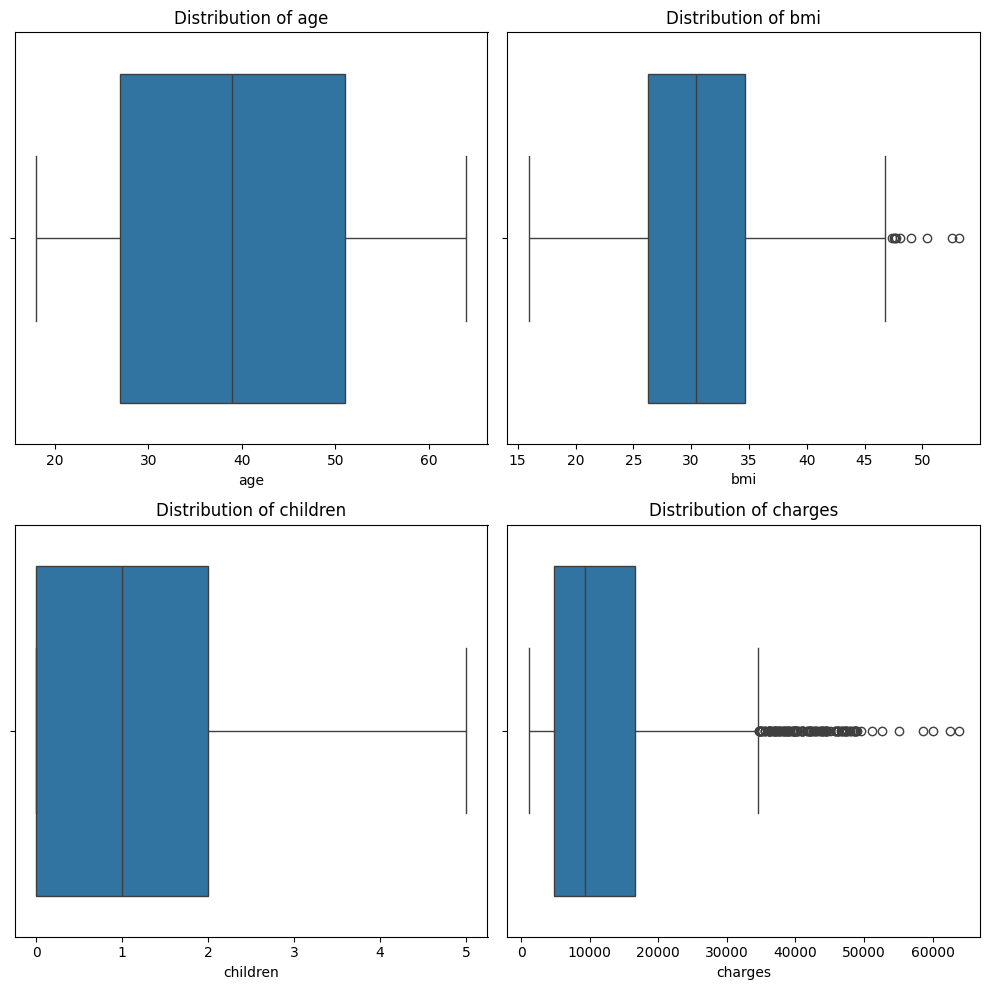

In [21]:
plt.figure(figsize=(10, 10))

for i, col in enumerate(continous_data.columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=continous_data[col])
    plt.xlabel(col)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


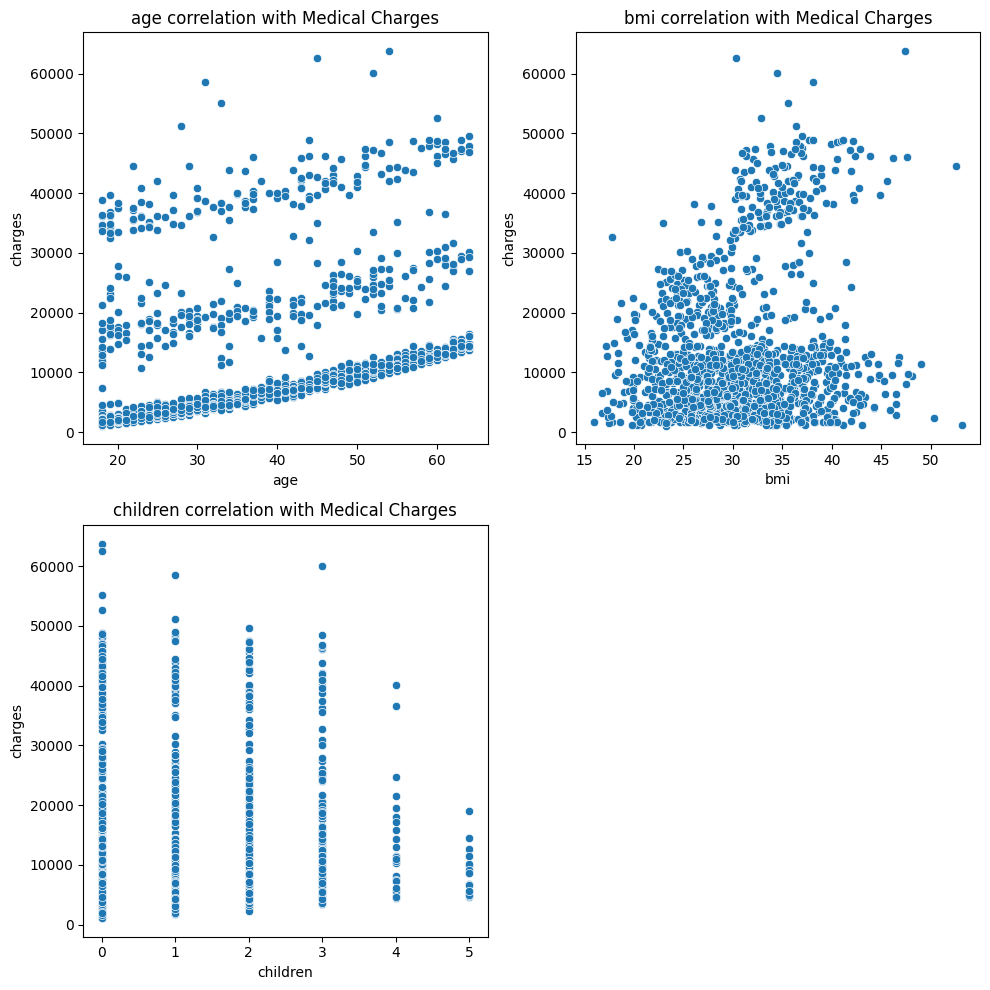

In [24]:
plt.figure(figsize=(10, 10))

predictors = ['age', 'bmi', 'children']

for i, col in enumerate(predictors):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=insurance[col], y=insurance['charges'])
    plt.xlabel(col)
    plt.ylabel('charges')
    plt.title(f'{col} correlation with Medical Charges')

plt.tight_layout()
plt.show()


In [27]:
categorial_data = insurance.select_dtypes(include=['object'])
categorial_data

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


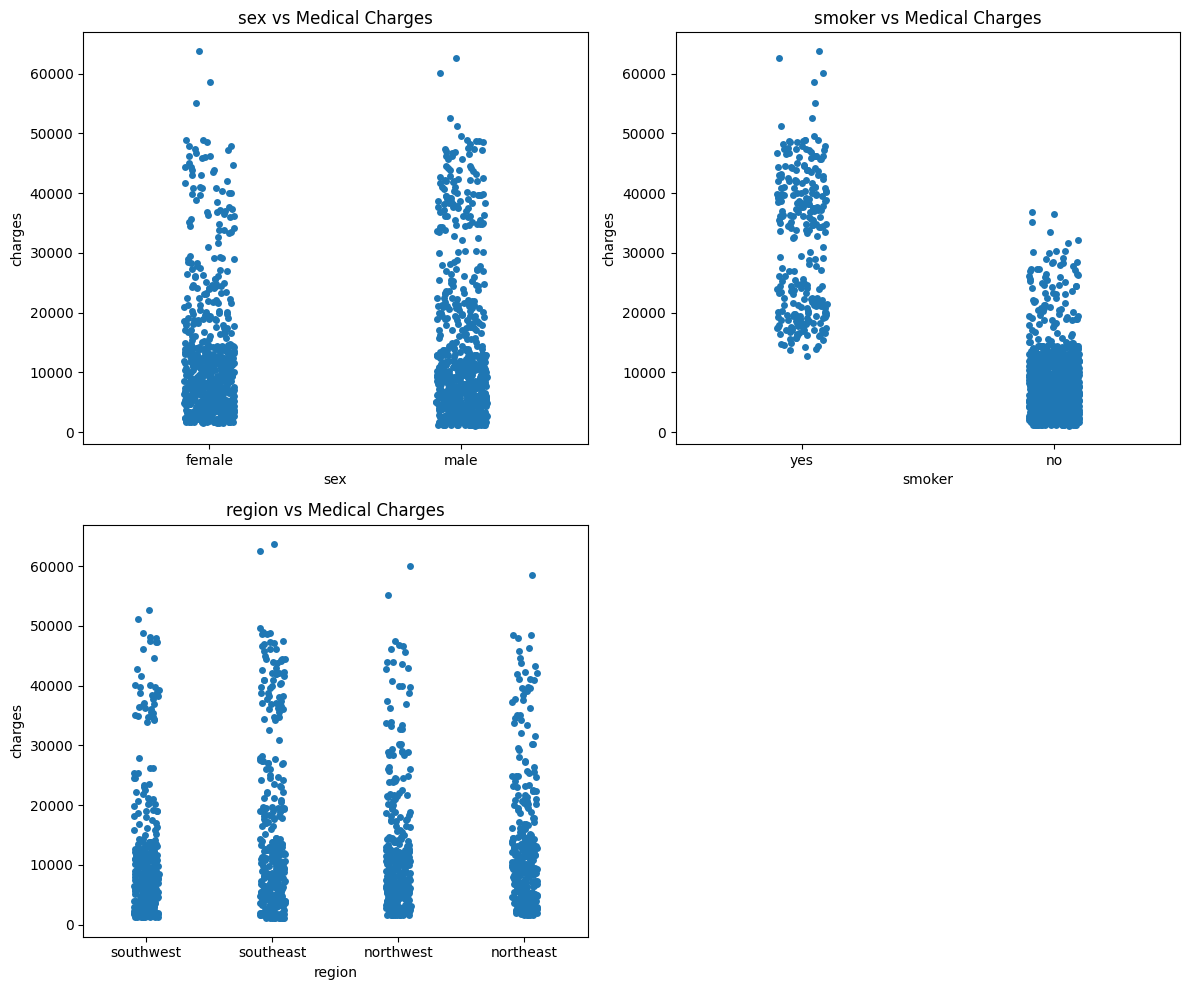

c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

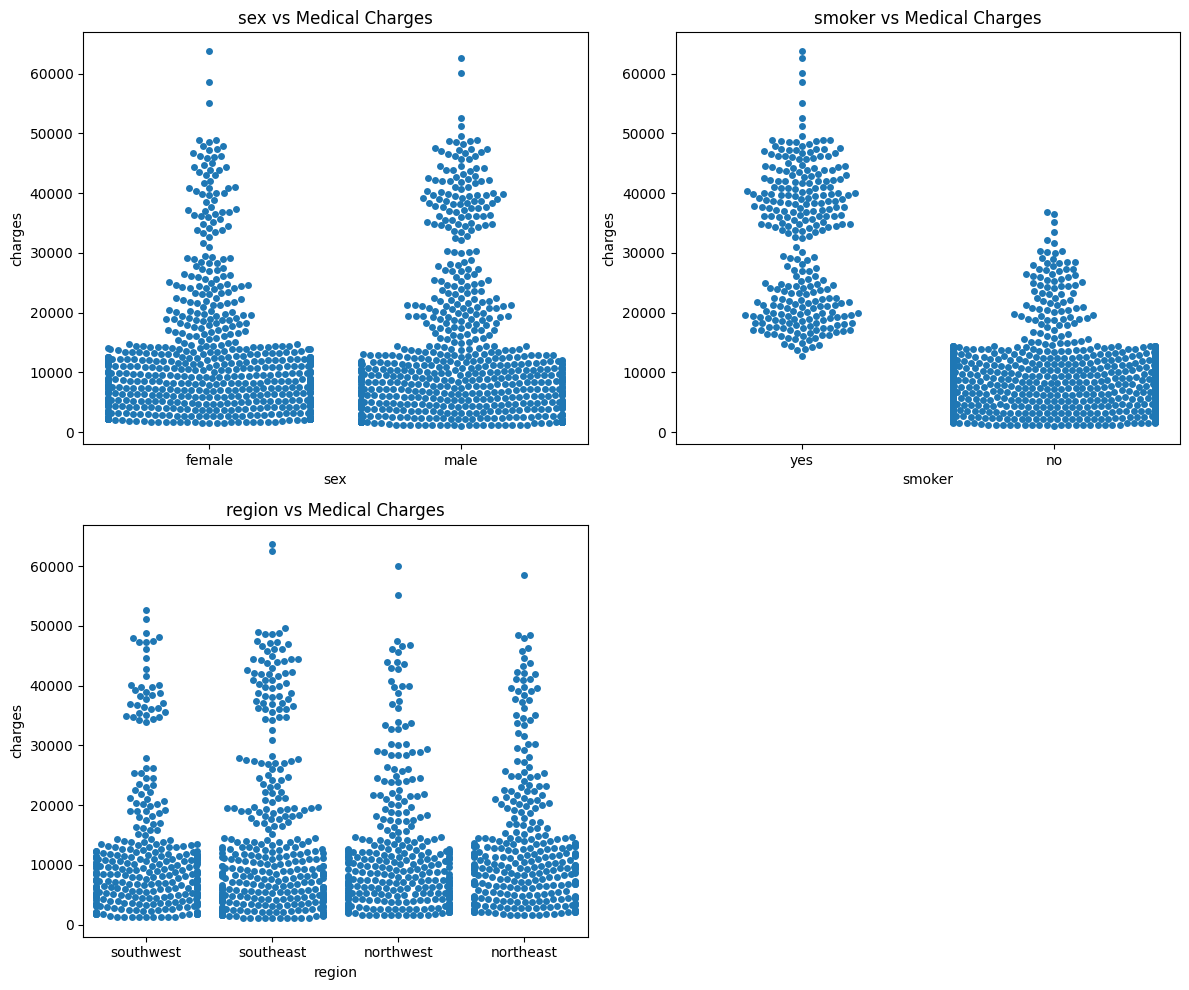

In [58]:
categorical_vars = ['sex', 'smoker', 'region']

plt.figure(figsize=(12, 10))

for i, col in enumerate(categorical_vars):
    plt.subplot(2, 2, i + 1)
    sns.stripplot(x=insurance[col], y=insurance['charges'], jitter=True)
    plt.xlabel(col)
    plt.ylabel('charges')
    plt.title(f'{col} vs Medical Charges')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))

for i, col in enumerate(categorical_vars):
    plt.subplot(2, 2, i + 1)
    sns.swarmplot(x=insurance[col], y=insurance['charges'])
    plt.xlabel(col)
    plt.ylabel('charges')
    plt.title(f'{col} vs Medical Charges')

plt.tight_layout()
plt.show()

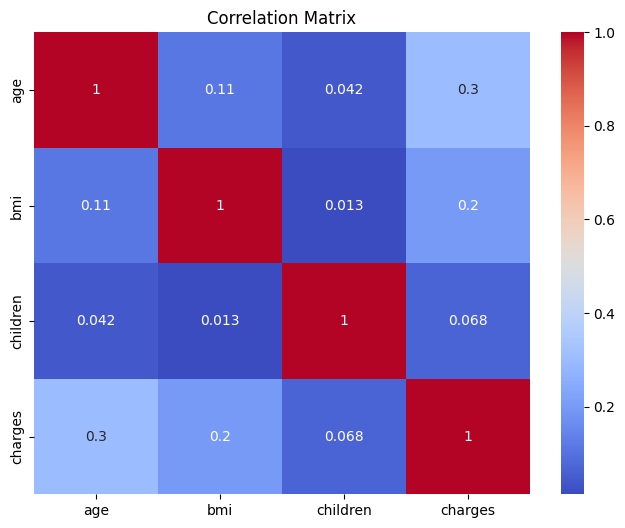

In [33]:
# Select numerical variables
numerical_vars = ['age', 'bmi', 'children', 'charges']

# Compute correlation matrix
corr = insurance[numerical_vars].corr()
corr

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


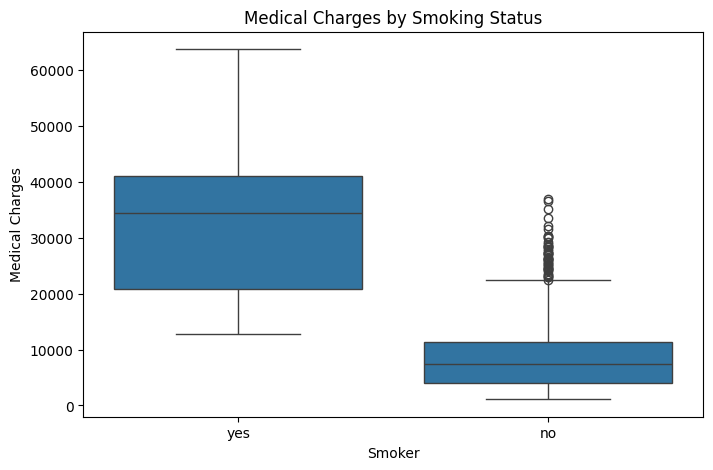

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=insurance)
plt.xlabel('Smoker')
plt.ylabel('Medical Charges')
plt.title('Medical Charges by Smoking Status')
plt.show()


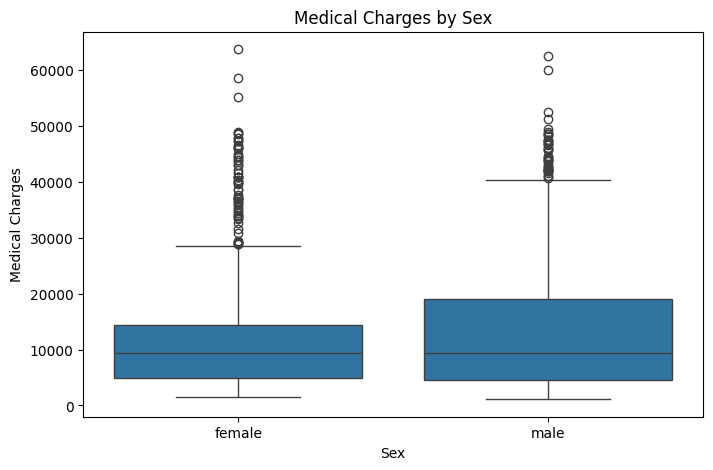

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='charges', data=insurance)
plt.xlabel('Sex')
plt.ylabel('Medical Charges')
plt.title('Medical Charges by Sex')
plt.show()


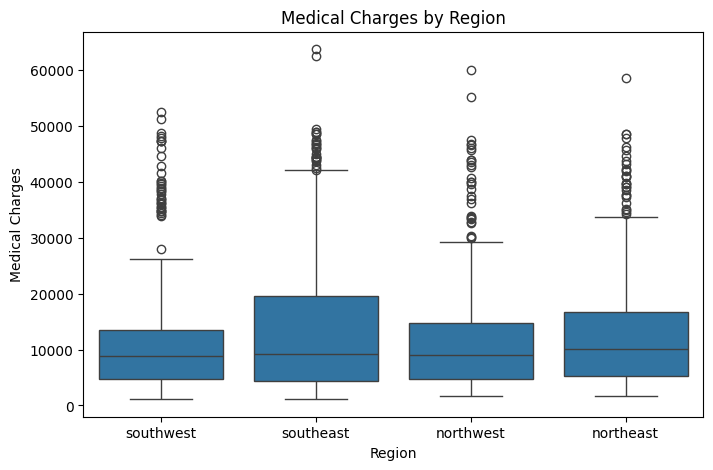

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=insurance)
plt.xlabel('Region')
plt.ylabel('Medical Charges')
plt.title('Medical Charges by Region')
plt.show()


In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Prepare data
X_slr = insurance[['bmi']]
y = insurance['charges']

# Split data (Step 6 requirement)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_slr, y, test_size=0.2, random_state=42)

# Train model
slr_model = LinearRegression()
slr_model.fit(X_train_s, y_train_s)

# Results
intercept = slr_model.intercept_
slope = slr_model.coef_[0]

print(f"Regression Equation: Charges = {intercept:.2f} + {slope:.2f} * Bmi")

Regression Equation: Charges = 1353.07 + 392.44 * Bmi


In [47]:
y_pred_s = slr_model.predict(X_test_s)

In [57]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_m = slr_model.predict(X_test_s)

# Metrics
mse = mean_squared_error(y_test_s, y_pred_s)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, y_pred_s)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 149085057.04
RMSE: 12210.04
R² Score: 0.0397


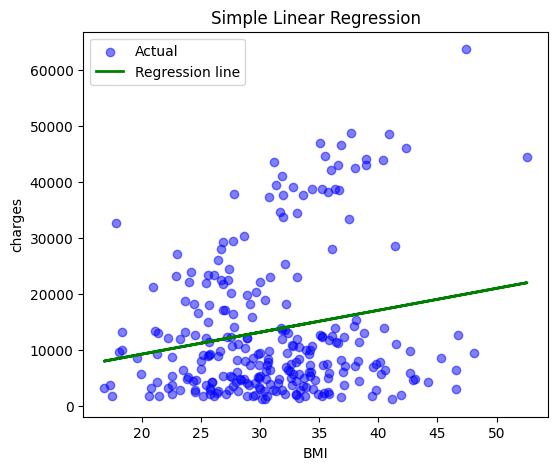

In [50]:
plt.figure(figsize=(6,5))
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_s, y_pred_s, color='green', linewidth=2, label='Regression line')
plt.xlabel('BMI')
plt.ylabel('charges')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [44]:
# Preprocessing categorical variables
categorical_encoded = pd.get_dummies(insurance, drop_first=True)

# Predictors: age, bmi, children, smoker_yes
X_mlr = categorical_encoded.drop('charges', axis=1)
y = categorical_encoded['charges']

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mlr, y, test_size=0.2, random_state=42)

# Train model
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)

# Display coefficients
coeff_df = pd.DataFrame(mlr_model.coef_, X_mlr.columns, columns=['Coefficient'])
print(coeff_df)

                   Coefficient
age                 256.975706
bmi                 337.092552
children            425.278784
sex_male            -18.591692
smoker_yes        23651.128856
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_m = mlr_model.predict(X_test_m)

# Metrics
mse = mean_squared_error(y_test_m, y_pred_m)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_m, y_pred_m)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 33596915.85
RMSE: 5796.28
R² Score: 0.7836


C:\Users\chari\AppData\Local\Temp\ipykernel_36888\3779837554.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


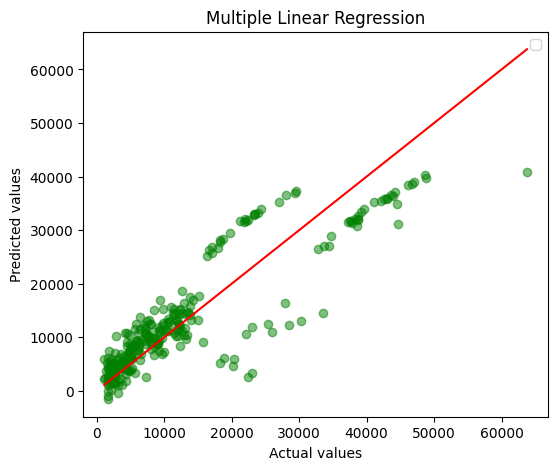

In [56]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_m, y_pred_m, color='green', alpha=0.5)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r-')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Multiple Linear Regression')
plt.legend()
plt.show()